<a href="https://colab.research.google.com/github/OdysseusPolymetis/tragic_influence_Litterature/blob/main/tragic_influence_temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Influence des tragiques grecs sur Sénèque
## Pipeline principal

Ce notebook met en œuvre un pipeline d'analyse intertextuelle entre les tragédies de Sénèque et les tragiques grecs, avec :

- chargement de corpus TEI Perseus ;
- normalisation et segmentation multi-niveaux ;
- encodage sémantique avec un modèle LaBSE finetuné ;
- matching Sénèque ↔ tragiques grecs bruts ;
- mesure de distinctivité d’auteur par voisinage contrastif ;
- contrôle contre le reste du corpus grec.

In [1]:
import os
import re
import glob
import math
import pickle
import random
import shutil
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from lxml import etree
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
# =========================
# CONFIGURATION GÉNÉRALE
# =========================

BASE_DIR = Path("/content")

GREEK_REPO = BASE_DIR / "canonical-greekLit" / "data"
LATIN_REPO = BASE_DIR / "canonical-latinLit" / "data"
TREEBANK_REPO = BASE_DIR / "treebank_data"

CACHE_DIR = BASE_DIR / "cache"
RESULTS_DIR = BASE_DIR / "results"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Modèle
MODEL_NAME = "/content/finetuned-labse/finetuned-labse"
MODEL_LABEL = "LaBSE-finetuned"
DEVICE = "cuda"
BATCH_SIZE = 32
NORMALIZE_EMBEDDINGS = True

# Segmentation
LEXICAL_MIN_WORDS = 5
LEXICAL_MAX_WORDS = 20
THEMATIC_WINDOW = 3
STRUCTURAL_WINDOW = 8

# KNN contrastif
K_NEIGHBORS = 5

# Reranking optionnel
ALPHA_AUTHOR = 0.10
BETA_GENERAL = 0.10

In [34]:
greek_tragedians = {
    "sophocles": ["tlg0011"],
    "aeschylus": ["tlg0085"],
    "euripides": ["tlg0006"],
}

dramatic_reference = {
    "comedy": [
        "tlg0019",
        "tlg0039",
    ],
    "other_tragedy": [
        # à compléter si besoin
    ]
}

non_dramatic_reference = {
    "epic": ["tlg0012", "tlg0020"],
    "prose": ["tlg0016", "tlg0003"],
    "philosophy": ["tlg0059", "tlg0086"],
}

seneca_tragedies = {
    "phi001": "Hercules Furens",
    "phi002": "Troades",
    "phi003": "Phoenissae",
    "phi004": "Medea",
    "phi005": "Phaedra",
    "phi006": "Oedipus",
    "phi007": "Agamemnon",
    "phi008": "Thyestes",
    "phi009": "Hercules Oetaeus",
}

In [35]:
print("Corpus définis :")
print(f"  Tragiques grecs : {list(greek_tragedians.keys())}")
print(f"  Référence dramatique : {list(dramatic_reference.keys())}")
print(f"  Référence non dramatique : {list(non_dramatic_reference.keys())}")
print(f"  Tragédies de Sénèque : {len(seneca_tragedies)}")

Corpus définis :
  Tragiques grecs : ['sophocles', 'aeschylus', 'euripides']
  Référence dramatique : ['comedy', 'other_tragedy']
  Référence non dramatique : ['epic', 'prose', 'philosophy']
  Tragédies de Sénèque : 9


In [36]:
TEI_NS = {"tei": "http://www.tei-c.org/ns/1.0"}

def parse_tei_body(xml_path):
    parser = etree.XMLParser(recover=True)
    tree = etree.parse(str(xml_path), parser)
    body = tree.find(".//tei:body", namespaces=TEI_NS)
    if body is None:
        return ""
    return " ".join(body.itertext())

In [37]:
def extract_tei_title(xml_path):
    parser = etree.XMLParser(recover=True)
    tree = etree.parse(str(xml_path), parser)

    title_el = tree.find(".//tei:titleStmt/tei:title", namespaces=TEI_NS)
    if title_el is not None:
        title_text = " ".join(title_el.itertext()).strip()
        if title_text:
            return title_text

    return Path(xml_path).stem

In [38]:
def normalize_text(text):
    if not text:
        return ""

    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"[\[\]{}()<>]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[\"“”‘’.,;:!?·…—–\\/_|*=+#-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [39]:
def list_author_works(repo_dir, author_id):
    author_dir = repo_dir / author_id
    if not author_dir.exists():
        return []
    return sorted([p.name for p in author_dir.iterdir() if p.is_dir()])

In [40]:
def resolve_perseus_xml(repo_dir, author_id, work_id, lang_pref=None):
    work_dir = repo_dir / author_id / work_id
    if not work_dir.exists():
        return None

    xml_candidates = sorted(work_dir.glob("*.xml"))
    if not xml_candidates:
        return None

    preferred_prefix = f"{author_id}.{work_id}"
    candidates = [p for p in xml_candidates if p.name.startswith(preferred_prefix)]
    if not candidates:
        candidates = xml_candidates

    if lang_pref == "grc":
        grc_candidates = [p for p in candidates if "-grc" in p.name or ".grc" in p.name]
        if grc_candidates:
            return grc_candidates[0]

    if lang_pref == "lat":
        lat_candidates = [p for p in candidates if "-lat" in p.name or ".lat" in p.name]
        if lat_candidates:
            return lat_candidates[0]

    if lang_pref == "eng":
        eng_candidates = [p for p in candidates if "-eng" in p.name or ".eng" in p.name]
        if eng_candidates:
            return eng_candidates[0]

    non_eng = [p for p in candidates if "-eng" not in p.name and ".eng" not in p.name]
    if non_eng:
        return non_eng[0]

    return candidates[0]

In [41]:
def load_seneca_corpus():
    rows = []
    author_id = "phi1017"

    for work_id, work_label in seneca_tragedies.items():
        fp = resolve_perseus_xml(LATIN_REPO, author_id, work_id, lang_pref="lat")

        if fp is None:
            print(f"[WARN] Introuvable : {author_id}/{work_id}")
            continue

        raw_text = parse_tei_body(fp)
        clean_text = normalize_text(raw_text)

        rows.append({
            "corpus_type": "seneca_target",
            "author_group": "seneca",
            "author_id": author_id,
            "work_id": work_id,
            "work_label": work_label,
            "lang": "latin",
            "xml_path": str(fp),
            "raw_text": raw_text,
            "clean_text": clean_text,
        })

    return pd.DataFrame(rows)

In [42]:
def load_greek_author_corpus(author_label, author_ids):
    rows = []

    for author_id in author_ids:
        work_ids = list_author_works(GREEK_REPO, author_id)

        for work_id in tqdm(work_ids, desc=f"Loading Greek corpus: {author_label}/{author_id}"):
            fp = resolve_perseus_xml(GREEK_REPO, author_id, work_id, lang_pref="grc")

            if fp is None:
                continue

            raw_text = parse_tei_body(fp)
            clean_text = normalize_text(raw_text)
            work_label = extract_tei_title(fp)

            rows.append({
                "corpus_type": "greek_target",
                "author_group": author_label,
                "author_id": author_id,
                "work_id": work_id,
                "work_label": work_label,
                "lang": "greek",
                "xml_path": str(fp),
                "raw_text": raw_text,
                "clean_text": clean_text,
            })

    return pd.DataFrame(rows)

In [43]:
def load_reference_corpus(reference_dict, corpus_type):
    dfs = []

    for group_label, author_ids in reference_dict.items():
        rows = []

        for author_id in author_ids:
            work_ids = list_author_works(GREEK_REPO, author_id)

            for work_id in tqdm(work_ids, desc=f"Loading {corpus_type}: {group_label}/{author_id}"):
                fp = resolve_perseus_xml(GREEK_REPO, author_id, work_id, lang_pref="grc")

                if fp is None:
                    continue

                raw_text = parse_tei_body(fp)
                clean_text = normalize_text(raw_text)
                work_label = extract_tei_title(fp)

                rows.append({
                    "corpus_type": corpus_type,
                    "author_group": group_label,
                    "author_id": author_id,
                    "work_id": work_id,
                    "work_label": work_label,
                    "lang": "greek",
                    "xml_path": str(fp),
                    "raw_text": raw_text,
                    "clean_text": clean_text,
                })

        if rows:
            dfs.append(pd.DataFrame(rows))

    if dfs:
        return pd.concat(dfs, ignore_index=True)

    return pd.DataFrame()

In [44]:
!git clone https://github.com/PerseusDL/treebank_data.git
!git clone https://github.com/PerseusDL/canonical-latinLit.git
!git clone https://github.com/PerseusDL/canonical-greekLit.git

fatal: destination path 'treebank_data' already exists and is not an empty directory.
fatal: destination path 'canonical-latinLit' already exists and is not an empty directory.
fatal: destination path 'canonical-greekLit' already exists and is not an empty directory.


In [45]:
FILE_ID = "1O9bfQg-C0VyfKimJFHgaw8xi4GfuwtVP"
!wget --no-check-certificate "https://drive.usercontent.google.com/download?id={FILE_ID}&export=download&confirm=t" -O /content/finetuned-labse.zip

--2026-04-10 15:16:47--  https://drive.usercontent.google.com/download?id=1O9bfQg-C0VyfKimJFHgaw8xi4GfuwtVP&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.193.132, 2607:f8b0:4001:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.193.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1756158269 (1.6G) [application/octet-stream]
Saving to: ‘/content/finetuned-labse.zip’

/content/finetuned- 100%[===================>]   1.63G   121MB/s    in 12s     

2026-04-10 15:17:00 (143 MB/s) - ‘/content/finetuned-labse.zip’ saved [1756158269/1756158269]



In [46]:
import zipfile
import shutil
from pathlib import Path

MODEL_DIR = Path("/content/finetuned-labse")

if MODEL_DIR.exists():
    shutil.rmtree(MODEL_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile("/content/finetuned-labse.zip", "r") as zip_ref:
    zip_ref.extractall(MODEL_DIR)

print("Extraction terminée.")
print(sorted([p.name for p in MODEL_DIR.iterdir()])[:20])

Extraction terminée.
['finetuned-labse']


In [47]:
from pathlib import Path

def find_sentence_transformer_root(base_dir):
    base_dir = Path(base_dir)

    expected_files = {"modules.json", "config_sentence_transformers.json", "sentence_bert_config.json"}
    base_names = {p.name for p in base_dir.iterdir()} if base_dir.exists() else set()

    if expected_files & base_names:
        return base_dir

    subdirs = [p for p in base_dir.iterdir() if p.is_dir()]
    for subdir in subdirs:
        sub_names = {p.name for p in subdir.iterdir()}
        if expected_files & sub_names:
            return subdir

    return base_dir

MODEL_PATH = find_sentence_transformer_root(MODEL_DIR)
print("MODEL_PATH =", MODEL_PATH)

MODEL_PATH = /content/finetuned-labse/finetuned-labse


In [48]:
seneca_df = load_seneca_corpus()

greek_target_dfs = []
for author_label, author_ids in greek_tragedians.items():
    greek_target_dfs.append(load_greek_author_corpus(author_label, author_ids))
greek_target_df = pd.concat(greek_target_dfs, ignore_index=True)

dramatic_reference_df = load_reference_corpus(dramatic_reference, "greek_dramatic_reference")
non_dramatic_reference_df = load_reference_corpus(non_dramatic_reference, "greek_non_dramatic_reference")

Loading Greek corpus: sophocles/tlg0011:   0%|          | 0/8 [00:00<?, ?it/s]

Loading Greek corpus: aeschylus/tlg0085:   0%|          | 0/7 [00:00<?, ?it/s]

Loading Greek corpus: euripides/tlg0006:   0%|          | 0/19 [00:00<?, ?it/s]

Loading greek_dramatic_reference: comedy/tlg0019:   0%|          | 0/11 [00:00<?, ?it/s]

Loading greek_dramatic_reference: comedy/tlg0039: 0it [00:00, ?it/s]

...

Loading greek_non_dramatic_reference: epic/tlg0020:   0%|          | 0/3 [00:00<?, ?it/s]

Loading greek_non_dramatic_reference: prose/tlg0016:   0%|          | 0/1 [00:00<?, ?it/s]

Loading greek_non_dramatic_reference: prose/tlg0003:   0%|          | 0/1 [00:00<?, ?it/s]

Loading greek_non_dramatic_reference: philosophy/tlg0059:   0%|          | 0/36 [00:00<?, ?it/s]

Loading greek_non_dramatic_reference: philosophy/tlg0086:   0%|          | 0/9 [00:00<?, ?it/s]

In [49]:
print("Sénèque :", len(seneca_df))
print("Tragiques grecs :", len(greek_target_df))
print("Référence dramatique :", len(dramatic_reference_df))
print("Référence non dramatique :", len(non_dramatic_reference_df))

Sénèque : 9
Tragiques grecs : 34
Référence dramatique : 11
Référence non dramatique : 53


In [50]:
display(seneca_df[["work_id", "work_label", "xml_path"]].head())
display(greek_target_df[["author_group", "author_id", "work_id", "work_label"]].head())

,work_id,work_label,xml_path
0,phi001,Hercules Furens,/content/canonical-latinLit/data/phi1017/phi00...
1,phi002,Troades,/content/canonical-latinLit/data/phi1017/phi00...
2,phi003,Phoenissae,/content/canonical-latinLit/data/phi1017/phi00...
3,phi004,Medea,/content/canonical-latinLit/data/phi1017/phi00...
4,phi005,Phaedra,/content/canonical-latinLit/data/phi1017/phi00...


,author_group,author_id,work_id,work_label
0,sophocles,tlg0011,tlg001,Τραχίνιαι
1,sophocles,tlg0011,tlg002,Ἀντιγόνη
2,sophocles,tlg0011,tlg003,Αἴας
3,sophocles,tlg0011,tlg004,Οἰδίπους Τύραννος
4,sophocles,tlg0011,tlg005,Ἠλέκτρα


In [51]:
print("Fichiers anglais dans greek_target_df :", greek_target_df["xml_path"].str.contains("eng").sum())
print("Fichiers anglais dans dramatic_reference_df :", dramatic_reference_df["xml_path"].str.contains("eng").sum())
print("Fichiers anglais dans non_dramatic_reference_df :", non_dramatic_reference_df["xml_path"].str.contains("eng").sum())

Fichiers anglais dans greek_target_df : 0
Fichiers anglais dans dramatic_reference_df : 0
Fichiers anglais dans non_dramatic_reference_df : 0


In [52]:
def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    return [tok for tok in text.split() if tok.strip()]

In [53]:
def segment_text_lexical(text, min_words=5, max_words=20):
    tokens = simple_tokenize(text)
    segments = []

    current = []
    start_idx = 0

    for i, tok in enumerate(tokens):
        if not current:
            start_idx = i
        current.append(tok)

        if len(current) >= max_words:
            segments.append({
                "segment_text": " ".join(current),
                "start_token": start_idx,
                "end_token": i,
                "n_words": len(current),
            })
            current = []

    if len(current) >= min_words:
        segments.append({
            "segment_text": " ".join(current),
            "start_token": start_idx,
            "end_token": len(tokens) - 1,
            "n_words": len(current),
        })

    return segments

In [54]:
def build_lexical_segments_df(works_df, text_col="clean_text", min_words=5, max_words=20):
    rows = []

    for _, row in tqdm(works_df.iterrows(), total=len(works_df)):
        segments = segment_text_lexical(
            row[text_col],
            min_words=min_words,
            max_words=max_words
        )

        for idx, seg in enumerate(segments):
            rows.append({
                "corpus_type": row["corpus_type"],
                "author_group": row["author_group"],
                "author_id": row["author_id"],
                "work_id": row["work_id"],
                "work_label": row["work_label"],
                "lang": row["lang"],
                "level": "lexical",
                "segment_id": f'{row["author_id"]}_{row["work_id"]}_lex_{idx}',
                "segment_idx": idx,
                "segment_text": seg["segment_text"],
                "start_token": seg["start_token"],
                "end_token": seg["end_token"],
                "n_words": seg["n_words"],
                "xml_path": row["xml_path"],
            })

    return pd.DataFrame(rows)

In [55]:
def build_sliding_windows_from_lexical(lexical_df, window_size, level_name):
    rows = []

    grouped = (
        lexical_df
        .sort_values(["author_id", "work_id", "segment_idx"])
        .groupby(["corpus_type", "author_group", "author_id", "work_id", "work_label", "lang", "xml_path"])
    )

    for group_keys, group in grouped:
        corpus_type, author_group, author_id, work_id, work_label, lang, xml_path = group_keys
        group = group.sort_values("segment_idx").reset_index(drop=True)

        if len(group) < window_size:
            continue

        for i in range(len(group) - window_size + 1):
            window = group.iloc[i:i+window_size]
            segment_text = " ".join(window["segment_text"].tolist())

            rows.append({
                "corpus_type": corpus_type,
                "author_group": author_group,
                "author_id": author_id,
                "work_id": work_id,
                "work_label": work_label,
                "lang": lang,
                "level": level_name,
                "segment_id": f"{author_id}_{work_id}_{level_name}_{i}",
                "segment_idx": i,
                "segment_text": segment_text,
                "start_token": int(window["start_token"].min()),
                "end_token": int(window["end_token"].max()),
                "n_words": len(simple_tokenize(segment_text)),
                "xml_path": xml_path,
            })

    return pd.DataFrame(rows)

In [56]:
seneca_lex = build_lexical_segments_df(seneca_df, min_words=LEXICAL_MIN_WORDS, max_words=LEXICAL_MAX_WORDS)
greek_target_lex = build_lexical_segments_df(greek_target_df, min_words=LEXICAL_MIN_WORDS, max_words=LEXICAL_MAX_WORDS)
dramatic_reference_lex = build_lexical_segments_df(dramatic_reference_df, min_words=LEXICAL_MIN_WORDS, max_words=LEXICAL_MAX_WORDS)
non_dramatic_reference_lex = build_lexical_segments_df(non_dramatic_reference_df, min_words=LEXICAL_MIN_WORDS, max_words=LEXICAL_MAX_WORDS)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [57]:
seneca_them = build_sliding_windows_from_lexical(seneca_lex, THEMATIC_WINDOW, "thematic")
greek_target_them = build_sliding_windows_from_lexical(greek_target_lex, THEMATIC_WINDOW, "thematic")
dramatic_reference_them = build_sliding_windows_from_lexical(dramatic_reference_lex, THEMATIC_WINDOW, "thematic")
non_dramatic_reference_them = build_sliding_windows_from_lexical(non_dramatic_reference_lex, THEMATIC_WINDOW, "thematic")

In [58]:
seneca_struct = build_sliding_windows_from_lexical(seneca_lex, STRUCTURAL_WINDOW, "structural")
greek_target_struct = build_sliding_windows_from_lexical(greek_target_lex, STRUCTURAL_WINDOW, "structural")
dramatic_reference_struct = build_sliding_windows_from_lexical(dramatic_reference_lex, STRUCTURAL_WINDOW, "structural")
non_dramatic_reference_struct = build_sliding_windows_from_lexical(non_dramatic_reference_lex, STRUCTURAL_WINDOW, "structural")

In [59]:
segmentation_summary = pd.DataFrame([
    {"corpus": "seneca", "level": "lexical", "n_segments": len(seneca_lex)},
    {"corpus": "seneca", "level": "thematic", "n_segments": len(seneca_them)},
    {"corpus": "seneca", "level": "structural", "n_segments": len(seneca_struct)},

    {"corpus": "greek_target", "level": "lexical", "n_segments": len(greek_target_lex)},
    {"corpus": "greek_target", "level": "thematic", "n_segments": len(greek_target_them)},
    {"corpus": "greek_target", "level": "structural", "n_segments": len(greek_target_struct)},

    {"corpus": "dramatic_reference", "level": "lexical", "n_segments": len(dramatic_reference_lex)},
    {"corpus": "dramatic_reference", "level": "thematic", "n_segments": len(dramatic_reference_them)},
    {"corpus": "dramatic_reference", "level": "structural", "n_segments": len(dramatic_reference_struct)},

    {"corpus": "non_dramatic_reference", "level": "lexical", "n_segments": len(non_dramatic_reference_lex)},
    {"corpus": "non_dramatic_reference", "level": "thematic", "n_segments": len(non_dramatic_reference_them)},
    {"corpus": "non_dramatic_reference", "level": "structural", "n_segments": len(non_dramatic_reference_struct)},
])

display(segmentation_summary)

,corpus,level,n_segments
0,seneca,lexical,3039
1,seneca,thematic,3021
2,seneca,structural,2976
3,greek_target,lexical,13106
4,greek_target,thematic,13038
5,greek_target,structural,12868
6,dramatic_reference,lexical,5111
7,dramatic_reference,thematic,5089
8,dramatic_reference,structural,5034
9,non_dramatic_reference,lexical,71609


In [60]:
class SegmentEncoder:
    def __init__(self, model_name, device="cuda"):
        self.model_name = model_name
        self.device = device
        self.model = SentenceTransformer(model_name, device=device)

    def encode(self, texts, batch_size=32, normalize_embeddings=True, show_progress_bar=True):
        return self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            convert_to_numpy=True,
            normalize_embeddings=normalize_embeddings
        )

In [62]:
encoder = SegmentEncoder(MODEL_NAME, device=DEVICE)
print("Modèle chargé :", MODEL_LABEL)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modèle chargé : LaBSE-finetuned


In [63]:
def get_embedding_cache_path(cache_name, model_label=MODEL_LABEL):
    safe_name = cache_name.replace("/", "_")
    return CACHE_DIR / f"{safe_name}_{model_label}.npy"

In [64]:
def encode_or_load(df, cache_name, text_col="segment_text"):
    cache_path = get_embedding_cache_path(cache_name)

    if cache_path.exists():
        print(f"Chargement du cache : {cache_path}")
        emb = np.load(cache_path)

        if len(emb) != len(df):
            print(f"[WARN] Cache invalide pour {cache_name}: {len(emb)} embeddings pour {len(df)} lignes. Réencodage.")
            emb = encoder.encode(
                df[text_col].tolist(),
                batch_size=BATCH_SIZE,
                normalize_embeddings=NORMALIZE_EMBEDDINGS,
                show_progress_bar=True
            )
            np.save(cache_path, emb)
    else:
        print(f"Encodage en cours : {cache_name}")
        emb = encoder.encode(
            df[text_col].tolist(),
            batch_size=BATCH_SIZE,
            normalize_embeddings=NORMALIZE_EMBEDDINGS,
            show_progress_bar=True
        )
        np.save(cache_path, emb)

    return emb

In [65]:
seneca_embeddings = {
    "lexical": encode_or_load(seneca_lex, "seneca_lex"),
    "thematic": encode_or_load(seneca_them, "seneca_them"),
    "structural": encode_or_load(seneca_struct, "seneca_struct"),
}

Encodage en cours : seneca_lex


Batches:   0%|          | 0/95 [00:00<?, ?it/s]

Encodage en cours : seneca_them


Batches:   0%|          | 0/95 [00:00<?, ?it/s]

Encodage en cours : seneca_struct


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

In [66]:
greek_target_embeddings = {
    "lexical": encode_or_load(greek_target_lex, "greek_target_lex"),
    "thematic": encode_or_load(greek_target_them, "greek_target_them"),
    "structural": encode_or_load(greek_target_struct, "greek_target_struct"),
}

Encodage en cours : greek_target_lex


Batches:   0%|          | 0/410 [00:00<?, ?it/s]

Encodage en cours : greek_target_them


Batches:   0%|          | 0/408 [00:00<?, ?it/s]

Encodage en cours : greek_target_struct


Batches:   0%|          | 0/403 [00:00<?, ?it/s]

In [67]:
dramatic_reference_embeddings = {
    "lexical": encode_or_load(dramatic_reference_lex, "dramatic_reference_lex"),
    "thematic": encode_or_load(dramatic_reference_them, "dramatic_reference_them"),
    "structural": encode_or_load(dramatic_reference_struct, "dramatic_reference_struct"),
}

non_dramatic_reference_embeddings = {
    "lexical": encode_or_load(non_dramatic_reference_lex, "non_dramatic_reference_lex"),
    "thematic": encode_or_load(non_dramatic_reference_them, "non_dramatic_reference_them"),
    "structural": encode_or_load(non_dramatic_reference_struct, "non_dramatic_reference_struct"),
}

Encodage en cours : dramatic_reference_lex


Batches:   0%|          | 0/160 [00:00<?, ?it/s]

Encodage en cours : dramatic_reference_them


Batches:   0%|          | 0/160 [00:00<?, ?it/s]

Encodage en cours : dramatic_reference_struct


...

Batches:   0%|          | 0/2238 [00:00<?, ?it/s]

Encodage en cours : non_dramatic_reference_them


Batches:   0%|          | 0/2235 [00:00<?, ?it/s]

Encodage en cours : non_dramatic_reference_struct


Batches:   0%|          | 0/2227 [00:00<?, ?it/s]

In [68]:
print("Sénèque")
for level, emb in seneca_embeddings.items():
    print(level, len({"lexical": seneca_lex, "thematic": seneca_them, "structural": seneca_struct}[level]), emb.shape)

print("\nTragiques grecs")
for level, emb in greek_target_embeddings.items():
    print(level, len({"lexical": greek_target_lex, "thematic": greek_target_them, "structural": greek_target_struct}[level]), emb.shape)

print("\nRéférence dramatique")
for level, emb in dramatic_reference_embeddings.items():
    print(level, len({"lexical": dramatic_reference_lex, "thematic": dramatic_reference_them, "structural": dramatic_reference_struct}[level]), emb.shape)

print("\nRéférence non dramatique")
for level, emb in non_dramatic_reference_embeddings.items():
    print(level, len({"lexical": non_dramatic_reference_lex, "thematic": non_dramatic_reference_them, "structural": non_dramatic_reference_struct}[level]), emb.shape)

Sénèque
lexical 3039 (3039, 768)
thematic 3021 (3021, 768)
structural 2976 (2976, 768)

Tragiques grecs
lexical 13106 (13106, 768)
thematic 13038 (13038, 768)
structural 12868 (12868, 768)

Référence dramatique
lexical 5111 (5111, 768)
thematic 5089 (5089, 768)
structural 5034 (5034, 768)

Référence non dramatique
lexical 71609 (71609, 768)
thematic 71503 (71503, 768)
structural 71238 (71238, 768)


In [69]:
def compute_best_matches(source_df, target_df, source_emb, target_emb, target_group_label="target"):
    if len(source_df) == 0:
        raise ValueError("source_df est vide")
    if len(target_df) == 0:
        raise ValueError("target_df est vide")
    if len(source_emb) != len(source_df):
        raise ValueError(f"source_emb ({len(source_emb)}) != len(source_df) ({len(source_df)})")
    if len(target_emb) != len(target_df):
        raise ValueError(f"target_emb ({len(target_emb)}) != len(target_df) ({len(target_df)})")

    sims = cosine_similarity(source_emb, target_emb)
    best_idx = sims.argmax(axis=1)
    best_scores = sims.max(axis=1)

    rows = []
    for i in range(len(source_df)):
        src = source_df.iloc[i]
        tgt = target_df.iloc[best_idx[i]]

        rows.append({
            "source_corpus_type": src["corpus_type"],
            "source_author_group": src["author_group"],
            "source_author_id": src["author_id"],
            "source_work_id": src["work_id"],
            "source_work_label": src["work_label"],
            "source_level": src["level"],
            "source_segment_id": src["segment_id"],
            "source_segment_idx": src["segment_idx"],
            "source_text": src["segment_text"],
            "source_n_words": src["n_words"],

            "target_corpus_type": tgt["corpus_type"],
            "target_author_group": tgt["author_group"],
            "target_author_id": tgt["author_id"],
            "target_work_id": tgt["work_id"],
            "target_work_label": tgt["work_label"],
            "target_segment_id": tgt["segment_id"],
            "target_segment_idx": tgt["segment_idx"],
            "target_text": tgt["segment_text"],
            "target_n_words": tgt["n_words"],

            "target_group_label": target_group_label,
            "cosine_similarity": float(best_scores[i]),
        })

    return pd.DataFrame(rows)

In [70]:
matches_greek_raw = {
    "lexical": compute_best_matches(
        seneca_lex, greek_target_lex,
        seneca_embeddings["lexical"], greek_target_embeddings["lexical"],
        target_group_label="greek_raw"
    ),
    "thematic": compute_best_matches(
        seneca_them, greek_target_them,
        seneca_embeddings["thematic"], greek_target_embeddings["thematic"],
        target_group_label="greek_raw"
    ),
    "structural": compute_best_matches(
        seneca_struct, greek_target_struct,
        seneca_embeddings["structural"], greek_target_embeddings["structural"],
        target_group_label="greek_raw"
    ),
}

In [71]:
matches_dramatic_reference = {
    "lexical": compute_best_matches(
        seneca_lex, dramatic_reference_lex,
        seneca_embeddings["lexical"], dramatic_reference_embeddings["lexical"],
        target_group_label="dramatic_reference"
    ),
    "thematic": compute_best_matches(
        seneca_them, dramatic_reference_them,
        seneca_embeddings["thematic"], dramatic_reference_embeddings["thematic"],
        target_group_label="dramatic_reference"
    ),
    "structural": compute_best_matches(
        seneca_struct, dramatic_reference_struct,
        seneca_embeddings["structural"], dramatic_reference_embeddings["structural"],
        target_group_label="dramatic_reference"
    ),
}

In [72]:
matches_non_dramatic_reference = {
    "lexical": compute_best_matches(
        seneca_lex, non_dramatic_reference_lex,
        seneca_embeddings["lexical"], non_dramatic_reference_embeddings["lexical"],
        target_group_label="non_dramatic_reference"
    ),
    "thematic": compute_best_matches(
        seneca_them, non_dramatic_reference_them,
        seneca_embeddings["thematic"], non_dramatic_reference_embeddings["thematic"],
        target_group_label="non_dramatic_reference"
    ),
    "structural": compute_best_matches(
        seneca_struct, non_dramatic_reference_struct,
        seneca_embeddings["structural"], non_dramatic_reference_embeddings["structural"],
        target_group_label="non_dramatic_reference"
    ),
}

In [73]:
print("Greek raw")
for level in ["lexical", "thematic", "structural"]:
    print(level, matches_greek_raw[level].shape)

print("\nDramatic reference")
for level in ["lexical", "thematic", "structural"]:
    print(level, matches_dramatic_reference[level].shape)

print("\nNon-dramatic reference")
for level in ["lexical", "thematic", "structural"]:
    print(level, matches_non_dramatic_reference[level].shape)

Greek raw
lexical (3039, 21)
thematic (3021, 21)
structural (2976, 21)

Dramatic reference
lexical (3039, 21)
thematic (3021, 21)
structural (2976, 21)

Non-dramatic reference
lexical (3039, 21)
thematic (3021, 21)
structural (2976, 21)


In [74]:
def mean_topk_similarities(query_emb, candidate_embs, k=5, exclude_self=False):
    """
    query_emb: (d,)
    candidate_embs: (n, d)
    """
    sims = cosine_similarity(query_emb.reshape(1, -1), candidate_embs).ravel()

    if exclude_self:
        sims = np.sort(sims)[::-1][1:k+1]
    else:
        sims = np.sort(sims)[::-1][:k]

    if len(sims) == 0:
        return np.nan

    return float(np.mean(sims))

In [77]:
def compute_greek_knn_margins_for_level(
    greek_df,
    greek_emb,
    dramatic_ref_df,
    dramatic_ref_emb,
    non_dramatic_ref_df,
    non_dramatic_ref_emb,
    k=5
):
    greek_df = greek_df.reset_index(drop=True).copy()

    # références générales
    general_ref_df = pd.concat([dramatic_ref_df, non_dramatic_ref_df], ignore_index=True)
    general_ref_emb = np.vstack([dramatic_ref_emb, non_dramatic_ref_emb])

    rows = []

    level_name = greek_df["level"].iloc[0] if len(greek_df) > 0 else "unknown"

    for idx, row in tqdm(
        greek_df.iterrows(),
        total=len(greek_df),
        desc=f"KNN margins {level_name}"
    ):
        seg_emb = greek_emb[idx]
        author = row["author_group"]

        same_mask = (greek_df["author_group"] == author).values
        other_mask = (greek_df["author_group"] != author).values

        same_emb = greek_emb[same_mask]
        other_emb = greek_emb[other_mask]

        within_author_sim = mean_topk_similarities(
            seg_emb, same_emb, k=k, exclude_self=True
        )
        other_authors_sim = mean_topk_similarities(
            seg_emb, other_emb, k=k, exclude_self=False
        )
        general_reference_sim = mean_topk_similarities(
            seg_emb, general_ref_emb, k=k, exclude_self=False
        )

        author_margin = within_author_sim - other_authors_sim
        general_margin = within_author_sim - general_reference_sim

        rows.append({
            "segment_id": row["segment_id"],
            "author_group": author,
            "work_id": row["work_id"],
            "work_label": row["work_label"],
            "level": row["level"],
            "within_author_sim": within_author_sim,
            "other_authors_sim": other_authors_sim,
            "general_reference_sim": general_reference_sim,
            "author_margin": author_margin,
            "general_margin": general_margin,
        })

    return pd.DataFrame(rows)

In [78]:
greek_knn_lex = compute_greek_knn_margins_for_level(
    greek_target_lex,
    greek_target_embeddings["lexical"],
    dramatic_reference_lex,
    dramatic_reference_embeddings["lexical"],
    non_dramatic_reference_lex,
    non_dramatic_reference_embeddings["lexical"],
    k=K_NEIGHBORS
)

KNN margins lexical:   0%|          | 0/13106 [00:00<?, ?it/s]

In [79]:
greek_knn_them = compute_greek_knn_margins_for_level(
    greek_target_them,
    greek_target_embeddings["thematic"],
    dramatic_reference_them,
    dramatic_reference_embeddings["thematic"],
    non_dramatic_reference_them,
    non_dramatic_reference_embeddings["thematic"],
    k=K_NEIGHBORS
)

KNN margins thematic:   0%|          | 0/13038 [00:00<?, ?it/s]

In [80]:
greek_knn_struct = compute_greek_knn_margins_for_level(
    greek_target_struct,
    greek_target_embeddings["structural"],
    dramatic_reference_struct,
    dramatic_reference_embeddings["structural"],
    non_dramatic_reference_struct,
    non_dramatic_reference_embeddings["structural"],
    k=K_NEIGHBORS
)

KNN margins structural:   0%|          | 0/12868 [00:00<?, ?it/s]

In [81]:
display(greek_knn_lex.head())
display(greek_knn_them.head())
display(greek_knn_struct.head())

,segment_id,author_group,work_id,work_label,level,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,tlg0011_tlg001_lex_0,sophocles,tlg001,Τραχίνιαι,lexical,0.722310,0.726909,0.739094,-0.004598,-0.016783
1,tlg0011_tlg001_lex_1,sophocles,tlg001,Τραχίνιαι,lexical,0.774642,0.770069,0.793894,0.004573,-0.019252
2,tlg0011_tlg001_lex_2,sophocles,tlg001,Τραχίνιαι,lexical,0.739006,0.746359,0.767573,-0.007353,-0.028566
3,tlg0011_tlg001_lex_3,sophocles,tlg001,Τραχίνιαι,lexical,0.734344,0.760980,0.747454,-0.026636,-0.013110
4,tlg0011_tlg001_lex_4,sophocles,tlg001,Τραχίνιαι,lexical,0.764391,0.778477,0.778983,-0.014086,-0.014592


,segment_id,author_group,work_id,work_label,level,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,tlg0085_tlg001_thematic_0,aeschylus,tlg001,Ἱκέτιδες,thematic,0.770150,0.769485,0.760452,0.000665,0.009698
1,tlg0085_tlg001_thematic_1,aeschylus,tlg001,Ἱκέτιδες,thematic,0.736565,0.741121,0.744684,-0.004556,-0.008119
2,tlg0085_tlg001_thematic_2,aeschylus,tlg001,Ἱκέτιδες,thematic,0.773600,0.754045,0.781326,0.019555,-0.007726
3,tlg0085_tlg001_thematic_3,aeschylus,tlg001,Ἱκέτιδες,thematic,0.778815,0.777059,0.784786,0.001755,-0.005972
4,tlg0085_tlg001_thematic_4,aeschylus,tlg001,Ἱκέτιδες,thematic,0.782691,0.748536,0.780061,0.034155,0.002630


,segment_id,author_group,work_id,work_label,level,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,tlg0085_tlg001_structural_0,aeschylus,tlg001,Ἱκέτιδες,structural,0.770150,0.769485,0.760452,0.000665,0.009698
1,tlg0085_tlg001_structural_1,aeschylus,tlg001,Ἱκέτιδες,structural,0.736565,0.741121,0.744684,-0.004556,-0.008119
2,tlg0085_tlg001_structural_2,aeschylus,tlg001,Ἱκέτιδες,structural,0.773600,0.754045,0.781326,0.019555,-0.007726
3,tlg0085_tlg001_structural_3,aeschylus,tlg001,Ἱκέτιδες,structural,0.778815,0.777059,0.784786,0.001755,-0.005972
4,tlg0085_tlg001_structural_4,aeschylus,tlg001,Ἱκέτιδες,structural,0.782691,0.748536,0.780061,0.034155,0.002630


In [88]:
def summarize_knn_margins(knn_df):
    return (
        knn_df.groupby("author_group")
        .agg(
            n_segments=("segment_id", "count"),
            mean_within_author_sim=("within_author_sim", "mean"),
            mean_other_authors_sim=("other_authors_sim", "mean"),
            mean_general_reference_sim=("general_reference_sim", "mean"),
            mean_author_margin=("author_margin", "mean"),
            mean_general_margin=("general_margin", "mean"),
        )
        .reset_index()
    )

display(summarize_knn_margins(greek_knn_lex))
display(summarize_knn_margins(greek_knn_them))
display(summarize_knn_margins(greek_knn_struct))

,author_group,n_segments,mean_within_author_sim,mean_other_authors_sim,mean_general_reference_sim,mean_author_margin,mean_general_margin
0,aeschylus,2094,0.750471,0.764605,0.766491,-0.014134,-0.016020
1,euripides,7746,0.763934,0.754977,0.767564,0.008957,-0.003631
2,sophocles,3266,0.753693,0.763588,0.770006,-0.009894,-0.016312


,author_group,n_segments,mean_within_author_sim,mean_other_authors_sim,mean_general_reference_sim,mean_author_margin,mean_general_margin
0,aeschylus,2080,0.797624,0.791429,0.787949,0.006194,0.009674
1,euripides,7708,0.807439,0.784418,0.790193,0.023021,0.017247
2,sophocles,3250,0.802672,0.791638,0.791701,0.011034,0.010971


,author_group,n_segments,mean_within_author_sim,mean_other_authors_sim,mean_general_reference_sim,mean_author_margin,mean_general_margin
0,aeschylus,2045,0.797279,0.791191,0.787755,0.006088,0.009524
1,euripides,7613,0.807246,0.784221,0.790083,0.023024,0.017163
2,sophocles,3210,0.802552,0.791524,0.791665,0.011028,0.010887


In [89]:
def attach_knn_margins_to_matches(matches_df, knn_df):
    return matches_df.merge(
        knn_df[["segment_id", "within_author_sim", "other_authors_sim", "general_reference_sim", "author_margin", "general_margin"]],
        left_on="target_segment_id",
        right_on="segment_id",
        how="left"
    ).drop(columns=["segment_id"])

In [90]:
matches_greek = {
    "lexical": attach_knn_margins_to_matches(matches_greek_raw["lexical"], greek_knn_lex),
    "thematic": attach_knn_margins_to_matches(matches_greek_raw["thematic"], greek_knn_them),
    "structural": attach_knn_margins_to_matches(matches_greek_raw["structural"], greek_knn_struct),
}

In [91]:
display(matches_greek["lexical"].head())
display(matches_greek["thematic"].head())
display(matches_greek["structural"].head())

,source_corpus_type,source_author_group,source_author_id,source_work_id,source_work_label,source_level,source_segment_id,source_segment_idx,source_text,source_n_words,...,target_segment_idx,target_text,target_n_words,target_group_label,cosine_similarity,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,seneca_target,seneca,phi1017,phi001,Hercules Furens,lexical,phi1017_phi001_lex_0,0,iuno soror tonantis hoc enim solum mihi nomen ...,20,...,166,ἅψωμαί τινος τόδʼ οὐκ ἐᾷ με παρακαλεῖ δʼ ἐκεῖθ...,20,greek_raw,0.711399,0.755196,0.755461,0.768160,-0.000265,-0.012964
1,seneca_target,seneca,phi1017,phi001,Hercules Furens,lexical,phi1017_phi001_lex_1,1,caelo pulsa paelicibus dedi tellus colenda est...,20,...,218,νέμει σεμνὸν τέρμονα κυρῶν οὐρανοῦ τὸν ἄτλας ἔ...,20,greek_raw,0.698325,0.769746,0.774923,0.779996,-0.005177,-0.010250
2,seneca_target,seneca,phi1017,phi001,Hercules Furens,lexical,phi1017_phi001_lex_2,2,agit hinc qua tepenti vere labatur dies tyriae...,20,...,239,τάλας τίνα τύχαν σέθεν βαρύποτμον γύναι προσαυ...,20,greek_raw,0.753650,0.803877,0.810060,0.821025,-0.006184,-0.017148
3,seneca_target,seneca,phi1017,phi001,Hercules Furens,lexical,phi1017_phi001_lex_3,3,vagantes exerunt atlantides ferro minax hinc t...,20,...,40,νιν οἶδε δʼ αὐτὸς ὧν ἥκω πέρι ἅ τε ξυνεθέμην π...,20,greek_raw,0.715039,0.778921,0.788506,0.811195,-0.009585,-0.032274
4,seneca_target,seneca,phi1017,phi001,Hercules Furens,lexical,phi1017_phi001_lex_4,4,quibusque natis mobilis tellus stetit nec ipse...,20,...,60,γῆς οὐ γάρ τι τραχίς ἐστιν οὐδʼ ἀχαιικὸν πόλισ...,20,greek_raw,0.749286,0.803027,0.789925,0.804829,0.013102,-0.001802


,source_corpus_type,source_author_group,source_author_id,source_work_id,source_work_label,source_level,source_segment_id,source_segment_idx,source_text,source_n_words,...,target_segment_idx,target_text,target_n_words,target_group_label,cosine_similarity,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,seneca_target,seneca,phi1017,phi001,Hercules Furens,thematic,phi1017_phi001_thematic_0,0,iuno soror tonantis hoc enim solum mihi nomen ...,60,...,51,σφάγια δʼ ἅμʼ αὐτῷ γῆς φιλαίματοι ῥοαί ἀντιγόν...,60,greek_raw,0.720753,0.794997,0.781901,0.768133,0.013096,0.026863
1,seneca_target,seneca,phi1017,phi001,Hercules Furens,thematic,phi1017_phi001_thematic_1,1,caelo pulsa paelicibus dedi tellus colenda est...,60,...,298,ἕστηκε πέτραν ἣ τῶνδε δόμων ὑπερακρίζει τήνδʼ ...,60,greek_raw,0.713344,0.803732,0.791604,0.796813,0.012128,0.006919
2,seneca_target,seneca,phi1017,phi001,Hercules Furens,thematic,phi1017_phi001_thematic_2,2,agit hinc qua tepenti vere labatur dies tyriae...,60,...,298,ἕστηκε πέτραν ἣ τῶνδε δόμων ὑπερακρίζει τήνδʼ ...,60,greek_raw,0.715212,0.803732,0.791604,0.796813,0.012128,0.006919
3,seneca_target,seneca,phi1017,phi001,Hercules Furens,thematic,phi1017_phi001_thematic_3,3,vagantes exerunt atlantides ferro minax hinc t...,60,...,153,ἆ ἆ ἒ ἔ χρίει τις αὖ με τὰν τάλαιναν οἶστρος ε...,60,greek_raw,0.712005,0.814363,0.819403,0.813389,-0.005039,0.000975
4,seneca_target,seneca,phi1017,phi001,Hercules Furens,thematic,phi1017_phi001_thematic_4,4,quibusque natis mobilis tellus stetit nec ipse...,60,...,3,πρέπουσα ποίᾳ ξυμφορᾷ προσεικάσω πότερα δόμοισ...,60,greek_raw,0.731991,0.807327,0.820653,0.805668,-0.013326,0.001659


,source_corpus_type,source_author_group,source_author_id,source_work_id,source_work_label,source_level,source_segment_id,source_segment_idx,source_text,source_n_words,...,target_segment_idx,target_text,target_n_words,target_group_label,cosine_similarity,within_author_sim,other_authors_sim,general_reference_sim,author_margin,general_margin
0,seneca_target,seneca,phi1017,phi001,Hercules Furens,structural,phi1017_phi001_structural_0,0,iuno soror tonantis hoc enim solum mihi nomen ...,160,...,51,σφάγια δʼ ἅμʼ αὐτῷ γῆς φιλαίματοι ῥοαί ἀντιγόν...,160,greek_raw,0.709025,0.794997,0.781901,0.768133,0.013096,0.026863
1,seneca_target,seneca,phi1017,phi001,Hercules Furens,structural,phi1017_phi001_structural_1,1,caelo pulsa paelicibus dedi tellus colenda est...,160,...,298,ἕστηκε πέτραν ἣ τῶνδε δόμων ὑπερακρίζει τήνδʼ ...,160,greek_raw,0.680513,0.803732,0.791604,0.796813,0.012128,0.006919
2,seneca_target,seneca,phi1017,phi001,Hercules Furens,structural,phi1017_phi001_structural_2,2,agit hinc qua tepenti vere labatur dies tyriae...,160,...,51,σφάγια δʼ ἅμʼ αὐτῷ γῆς φιλαίματοι ῥοαί ἀντιγόν...,160,greek_raw,0.714784,0.794997,0.781901,0.768133,0.013096,0.026863
3,seneca_target,seneca,phi1017,phi001,Hercules Furens,structural,phi1017_phi001_structural_3,3,vagantes exerunt atlantides ferro minax hinc t...,160,...,153,ἆ ἆ ἒ ἔ χρίει τις αὖ με τὰν τάλαιναν οἶστρος ε...,160,greek_raw,0.702698,0.812105,0.819403,0.813389,-0.007297,-0.001283
4,seneca_target,seneca,phi1017,phi001,Hercules Furens,structural,phi1017_phi001_structural_4,4,quibusque natis mobilis tellus stetit nec ipse...,160,...,66,σφʼ ἑκών ὀρέστης ἄνασσʼ ἀθάνα λοξίου κελεύμασι...,160,greek_raw,0.728686,0.792295,0.783699,0.814566,0.008596,-0.022271


In [92]:
def summarize_similarity_distribution(matches_df, label=""):
    summary = matches_df["cosine_similarity"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"\n--- {label} ---")
    print(summary)
    return summary

In [93]:
for level in ["lexical", "thematic", "structural"]:
    summarize_similarity_distribution(matches_greek[level], f"Greek raw / {level}")
    summarize_similarity_distribution(matches_dramatic_reference[level], f"Dramatic reference / {level}")
    summarize_similarity_distribution(matches_non_dramatic_reference[level], f"Non-dramatic reference / {level}")


--- Greek raw / lexical ---
count    3039.000000
mean        0.751591
std         0.025472
min         0.619835
50%         0.752831
75%         0.769258
90%         0.783439
95%         0.790806
99%         0.804468
max         0.841881
Name: cosine_similarity, dtype: float64

--- Dramatic reference / lexical ---
count    3039.000000
mean        0.730506
std         0.027018
min         0.596810
50%         0.731445
75%         0.748865
90%         0.764353
95%         0.772527
99%         0.786754
max         0.844883
Name: cosine_similarity, dtype: float64

--- Non-dramatic reference / lexical ---
count    3039.000000
mean        0.754797
std         0.025221
min         0.625768
50%         0.755448
75%         0.772501
90%         0.786280
95%         0.793831
99%         0.808675
max         0.835292
Name: cosine_similarity, dtype: float64

--- Greek raw / thematic ---
count    3021.000000
mean        0.744581
std         0.023892
min         0.660763
50%         0.745291
75%   

In [96]:
def summarize_matches_by_greek_author(matches_df):
    agg_dict = {
        "n_matches": ("source_segment_id", "count"),
        "mean_cosine": ("cosine_similarity", "mean"),
        "median_cosine": ("cosine_similarity", "median"),
        "mean_author_margin": ("author_margin", "mean"),
        "mean_general_margin": ("general_margin", "mean"),
    }

    if "final_score" in matches_df.columns:
        agg_dict["mean_final_score"] = ("final_score", "mean")

    return (
        matches_df.groupby("target_author_group")
        .agg(**agg_dict)
        .reset_index()
        .sort_values("mean_cosine", ascending=False)
    )

In [97]:
display(summarize_matches_by_greek_author(matches_greek["lexical"]))
display(summarize_matches_by_greek_author(matches_greek["thematic"]))
display(summarize_matches_by_greek_author(matches_greek["structural"]))

,target_author_group,n_matches,mean_cosine,median_cosine,mean_author_margin,mean_general_margin
1,euripides,1797,0.752179,0.752899,0.007241,-0.006561
2,sophocles,707,0.751400,0.752914,-0.013883,-0.020670
0,aeschylus,535,0.749871,0.752677,-0.013391,-0.016424


,target_author_group,n_matches,mean_cosine,median_cosine,mean_author_margin,mean_general_margin
1,euripides,1555,0.747091,0.747498,0.020003,0.016542
2,sophocles,813,0.742519,0.743138,0.002155,0.003783
0,aeschylus,653,0.741170,0.742178,0.009013,0.010034


,target_author_group,n_matches,mean_cosine,median_cosine,mean_author_margin,mean_general_margin
1,euripides,1465,0.736763,0.737773,0.020161,0.018064
2,sophocles,838,0.733757,0.734424,0.002527,0.005280
0,aeschylus,673,0.731025,0.731106,0.010247,0.011688


## Analyse niveau Micro

In [98]:
def get_top_matches(matches_df, n=30, score_col="cosine_similarity", dedup_target=False):
    df = matches_df.copy().sort_values(score_col, ascending=False)

    if dedup_target:
        df = df.drop_duplicates(subset=["target_segment_id"])

    return df.head(n)[[
        "source_work_label",
        "source_segment_idx",
        "source_text",
        "target_author_group",
        "target_work_id",
        "target_work_label",
        "target_segment_idx",
        "target_text",
        "cosine_similarity",
        "author_margin",
        "general_margin",
    ]]

In [101]:
display(get_top_matches(matches_greek["thematic"], n=30, dedup_target=True))
display(get_top_matches(matches_greek["structural"], n=30, dedup_target=True))

,source_work_label,source_segment_idx,source_text,target_author_group,target_work_id,target_work_label,target_segment_idx,target_text,cosine_similarity,author_margin,general_margin
783,Phoenissae,62,deorum velle fac quicquam potest malis tuis ad...,euripides,tlg005,Ἱππόλυτος,88,θησεύς τιν ἡμάρτηκεν ἐς σ ἁμαρτίαν φαίδρα μὴ δ...,0.823915,0.019855,0.015971
2116,Agamemnon,253,str o nulla longi temporis felicitas el per te...,euripides,tlg016,Ὀρέστης,488,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...,0.814625,0.020306,0.024191
822,Phoenissae,101,muros castra thebanos premunt succurre prohibe...,aeschylus,tlg006,Χοηφóρoι,271,εἰμί κηρύσσω φίλοις κτανεῖν τέ φημι μητέρʼ οὐκ...,0.810764,-0.031747,-0.002234
2410,Thyestes,269,tempestas cum sine vento tranquilla tument quo...,sophocles,tlg001,Τραχίνιαι,304,τάσδε συμφοράς φίλαι ἄνακτος οἵαις οἷος ὢν ἐλα...,0.809033,0.014200,0.013374
2282,Thyestes,141,ego vos sequor non duco tant respiciet deus be...,sophocles,tlg002,Ἀντιγόνη,255,πέλει σὲ δʼ αὐτόγνωτος ὤλεσʼ ὀργά ἀντιγόνη ἄκλ...,0.808723,0.007866,0.010890
543,Troades,162,possedit errore avio vagus arva lustras vastus...,euripides,tlg016,Ὀρέστης,243,κακόν πυλάδης στρόφιος ἤλασέν μʼ ἀπʼ οἴκων φυγ...,0.807481,0.015434,0.035750
2008,Agamemnon,145,pontus atque undae ferunt ignava fortes fata c...,euripides,tlg007,Ἑκάβη,56,κακῶν τῶν σῶν σοφόν τοι κἀν κακοῖς ἃ δεῖ φρονε...,0.807140,0.022732,0.002013
1200,Medea,275,funus ac tumulum strue coniunx socerque iusta ...,euripides,tlg014,Ἑλένη,82,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...,0.805519,0.025917,0.021949
1629,Oedipus,62,vates spargere horrentes comas et pati commota...,sophocles,tlg001,Τραχίνιαι,254,δακρύων ἄχναν ἁ δʼ ἐρχομένα μοῖρα προφαίνει δο...,0.804376,0.000631,0.017047
344,Hercules Furens,344,inferorum carcer et sonti plaga decreta turbae...,euripides,tlg004,Ἡρακλεῖδαι,307,ἐχρῆν μʼ ἄρα μισούμενον πρὸς τῶνδε καὶ ξυνειδό...,0.804286,0.004480,0.013305


,source_work_label,source_segment_idx,source_text,target_author_group,target_work_id,target_work_label,target_segment_idx,target_text,cosine_similarity,author_margin,general_margin
640,Troades,264,puppis vestra si secuit freta sin rapta phrygi...,sophocles,tlg002,Ἀντιγόνη,172,οὐχ ὥς γʼ ἐκείνῳ τῇδέ τʼ ἦν ἡρμοσμένα κρέων κα...,0.795024,-0.006767,0.017577
2095,Agamemnon,262,doces clyt animos viriles corde tumefacto geri...,euripides,tlg002,Ἄλκηστις,188,κἀπὶ τέρμ ἥκων βίου οὐκ ἠθέλησας οὐδ ἐτόλμησας...,0.794894,0.064585,0.055596
2615,Hercules Oetaeus,200,metu semel profecto premere felices deus cum c...,sophocles,tlg001,Τραχίνιαι,304,τάσδε συμφοράς φίλαι ἄνακτος οἵαις οἷος ὢν ἐλα...,0.794217,0.014200,0.013374
1695,Oedipus,153,atque atrae boves intro trahuntur flamma praed...,euripides,tlg017,Βάκχαι,34,ῥεῖ δὲ γάλακτι πέδον ῥεῖ δʼ οἴνῳ ῥεῖ δὲ μελισσ...,0.792668,0.041273,0.013337
590,Troades,214,manus troiam erigent nullas habet spes troia s...,euripides,tlg014,Ἑλένη,252,ἄξια ἑλένη οὐκ ἂν κτάνοις τύραννον ὃ σπεύδεις ...,0.791527,0.028785,0.035239
538,Troades,162,possedit errore avio vagus arva lustras vastus...,euripides,tlg016,Ὀρέστης,243,κακόν πυλάδης στρόφιος ἤλασέν μʼ ἀπʼ οἴκων φυγ...,0.789569,0.015434,0.035750
2247,Thyestes,141,ego vos sequor non duco tant respiciet deus be...,sophocles,tlg002,Ἀντιγόνη,255,πέλει σὲ δʼ αὐτόγνωτος ὤλεσʼ ὀργά ἀντιγόνη ἄκλ...,0.789265,0.007866,0.010890
2701,Hercules Oetaeus,286,tibi haec haec peremit dextra cui debes patri ...,euripides,tlg003,Μήδεια,396,ἣ τυρσηνὸν ᾤκησεν πέδον τῆς σῆς γὰρ ὡς χρὴ καρ...,0.789107,0.027251,0.041293
2086,Agamemnon,253,str o nulla longi temporis felicitas el per te...,euripides,tlg016,Ὀρέστης,488,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...,0.789039,0.020306,0.024191
1502,Phaedra,314,quod voluit potens thes equidem malorum maximu...,sophocles,tlg007,Οἰδίπους ἐπὶ Κολωνῷ,386,τάχιστα ὡς εὖτʼ ἂν τὸ νέον παρῇ κούφας ἀφροσύν...,0.788328,0.014653,0.009377


In [102]:
def get_top_matches_for_play(matches_df, play_name, n=20, score_col="cosine_similarity", dedup_target=True):
    df = matches_df[matches_df["source_work_label"] == play_name].copy()
    df = df.sort_values(score_col, ascending=False)

    if dedup_target:
        df = df.drop_duplicates(subset=["target_segment_id"])

    return df.head(n)[[
        "source_work_label",
        "source_segment_idx",
        "source_text",
        "target_author_group",
        "target_work_id",
        "target_work_label",
        "target_segment_idx",
        "target_text",
        "cosine_similarity",
        "author_margin",
        "general_margin",
    ]]

In [103]:
display(get_top_matches_for_play(matches_greek["thematic"], "Medea", n=20))
display(get_top_matches_for_play(matches_greek["structural"], "Phaedra", n=20))

,source_work_label,source_segment_idx,source_text,target_author_group,target_work_id,target_work_label,target_segment_idx,target_text,cosine_similarity,author_margin,general_margin
1200,Medea,275,funus ac tumulum strue coniunx socerque iusta ...,euripides,tlg014,Ἑλένη,82,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...,0.805519,0.025917,0.021949
1174,Medea,249,exitium senis armasse natas quaere materiam do...,euripides,tlg005,Ἱππόλυτος,88,θησεύς τιν ἡμάρτηκεν ἐς σ ἁμαρτίαν φαίδρα μὴ δ...,0.803134,0.019855,0.015971
1205,Medea,280,ense viscera et ferro extraham ias iam perage ...,euripides,tlg016,Ὀρέστης,488,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...,0.801100,0.020306,0.024191
995,Medea,70,ex omni tuli hoc est penes te si placet damna ...,sophocles,tlg002,Ἀντιγόνη,11,οὐδέν ἀλλʼ ὃς ἂν τούτων τι δρᾷ φόνον προκεῖσθα...,0.800848,0.018110,0.003923
1091,Medea,166,artibus vocetur hecate sacra letifica appara s...,sophocles,tlg002,Ἀντιγόνη,177,δόμος ἄτας οὐδὲν ἐλλείπει γενεᾶς ἐπὶ πλῆθος ἕρ...,0.792724,-0.006567,0.015572
928,Medea,3,raptam voce non fausta precor nunc nunc adeste...,euripides,tlg006,Ἀνδρομάχη,359,οὐ σπαράξομαι κόμαν οὐκ ἐμῷ πιθήσομαι κάρᾳ κτύ...,0.792435,0.019976,0.041977
1064,Medea,139,med hoc suades mihi praestas creusae paelicem ...,euripides,tlg005,Ἱππόλυτος,89,σ ἐξαίρει θανεῖν φαίδρα ἔα μ ἁμαρτεῖν οὐ γὰρ ἐ...,0.791830,0.035244,0.034971
980,Medea,55,iube cr aequum atque iniquum regis imperium fe...,aeschylus,tlg001,Ἱκέτιδες,99,κρατῶν μὴ καί ποτε εἴπῃ λεώς εἴ πού τι μὴ τοῖο...,0.790850,0.018517,0.035890
1169,Medea,244,amas adhuc furiosa si satis est tibi caelebs i...,euripides,tlg005,Ἱππόλυτος,276,ὡς περισσὸς ὢν ἀνὴρ ξύνει σὺ σώφρων καὶ κακῶν ...,0.790806,0.016897,0.006089
946,Medea,21,nurus et quas taygeti iugis exercet iuvenum mo...,aeschylus,tlg002,Πέρσαι,59,χεροῖν αὐτοῖς πρέπει χορός οὐδαμῶς ἔγχη σταδαῖ...,0.790103,0.006161,0.015510


,source_work_label,source_segment_idx,source_text,target_author_group,target_work_id,target_work_label,target_segment_idx,target_text,cosine_similarity,author_margin,general_margin
1502,Phaedra,314,quod voluit potens thes equidem malorum maximu...,sophocles,tlg007,Οἰδίπους ἐπὶ Κολωνῷ,386,τάχιστα ὡς εὖτʼ ἂν τὸ νέον παρῇ κούφας ἀφροσύν...,0.788328,0.014653,0.009377
1534,Phaedra,346,ferus meumque poenae semper accrescat iecur et...,euripides,tlg013,Ἰφιγένεια ἐν Ταύροις,201,βωμὸν ἁγνισθεὶς φόνῳ καὶ μὴ προδῷς μου τὴν κασ...,0.784571,0.023908,0.033241
1311,Phaedra,123,evincet nemus quam non maligna caedit aut rese...,euripides,tlg016,Ὀρέστης,266,αὐγὰς ἀελίοιο δεῖξαι τὸ δʼ εὖ κακουργεῖν ἀσέβε...,0.783731,0.008218,0.006253
1363,Phaedra,175,fratres colam et te merebor esse ne viduam put...,euripides,tlg003,Μήδεια,334,μυσαχθεῖσ εἰσόδους πόσις δὲ σὸς ὀργάς τ ἀφῄρει...,0.783598,0.016838,0.006332
1428,Phaedra,240,malum iam perge quaeso perge properato est opu...,euripides,tlg016,Ὀρέστης,488,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...,0.783155,0.020306,0.024191
1405,Phaedra,217,deterior subit quid deserta petis tutior aviis...,aeschylus,tlg005,Ἀγαμέμνων,40,μάντιν οὔτινα ψέγων ἐμπαίοις τύχαισι συμπνέων ...,0.782873,0.002765,0.025003
1527,Phaedra,339,exsequor vindex severus incidi in verum scelus...,euripides,tlg009,Ἡρακλῆς,304,ἔμπνους μέν εἰμι καὶ δέδορχʼ ἅπερ με δεῖ αἰθέρ...,0.781455,0.044695,0.017858
1518,Phaedra,330,umbras capitis exuvias cape laceraeque frontis...,euripides,tlg016,Ὀρέστης,244,συνηράμην φόνον σοι μητρός ἀνόσιον λέγων ὀρέστ...,0.780879,0.005550,0.014664
1388,Phaedra,200,meo est salvo ut pudore manibus immoriar tuis ...,euripides,tlg006,Ἀνδρομάχη,359,οὐ σπαράξομαι κόμαν οὐκ ἐμῷ πιθήσομαι κάρᾳ κτύ...,0.780484,0.019976,0.041977
1213,Phaedra,25,nec adire castis precibus aut ritu pio adiudic...,euripides,tlg014,Ἑλένη,204,οὐκ ἐπὶ βαρβάρου λέκτρα νεανία πετομένας κώπας...,0.778322,0.017691,0.013923


### Timeline

In [104]:
def get_proximity_timeline(matches_df, play_name):
    df = matches_df[matches_df["source_work_label"] == play_name].copy()
    df = df.sort_values("source_segment_idx")
    return df[[
        "source_segment_idx",
        "cosine_similarity",
        "author_margin",
        "general_margin",
        "target_author_group",
        "target_work_id",
        "target_work_label",
        "target_segment_idx",
    ]]

In [105]:
timeline_medea_them = get_proximity_timeline(matches_greek["thematic"], "Medea")
display(timeline_medea_them.head(30))

,source_segment_idx,cosine_similarity,author_margin,general_margin,target_author_group,target_work_id,target_work_label,target_segment_idx
925,0,0.765563,0.006768,0.021120,euripides,tlg009,Ἡρακλῆς,303
926,1,0.759643,0.003579,0.043607,aeschylus,tlg001,Ἱκέτιδες,178
927,2,0.755823,0.014863,0.010257,sophocles,tlg006,Φιλοκτήτης,457
928,3,0.792435,0.019976,0.041977,euripides,tlg006,Ἀνδρομάχη,359
929,4,0.756873,0.040075,0.013607,euripides,tlg003,Μήδεια,297
930,5,0.743063,0.012922,0.029966,euripides,tlg015,Φοίνισσαι,67
931,6,0.747753,0.044695,0.017858,euripides,tlg009,Ἡρακλῆς,304
932,7,0.725015,0.019931,0.030056,aeschylus,tlg003,Προμηθεὺς δεσμώτης,6
933,8,0.757944,0.033943,-0.002529,euripides,tlg015,Φοίνισσαι,197
934,9,0.770951,0.012000,0.001409,sophocles,tlg004,Οἰδίπους Τύραννος,6


In [106]:
import matplotlib.pyplot as plt

def plot_proximity_timeline(matches_df, play_name, score_col="cosine_similarity"):
    df = get_proximity_timeline(matches_df, play_name)

    plt.figure(figsize=(12, 4))
    plt.plot(df["source_segment_idx"], df[score_col])
    plt.xlabel("Index du segment dans la pièce")
    plt.ylabel(score_col)
    plt.title(f"{play_name} — évolution de {score_col}")
    plt.show()

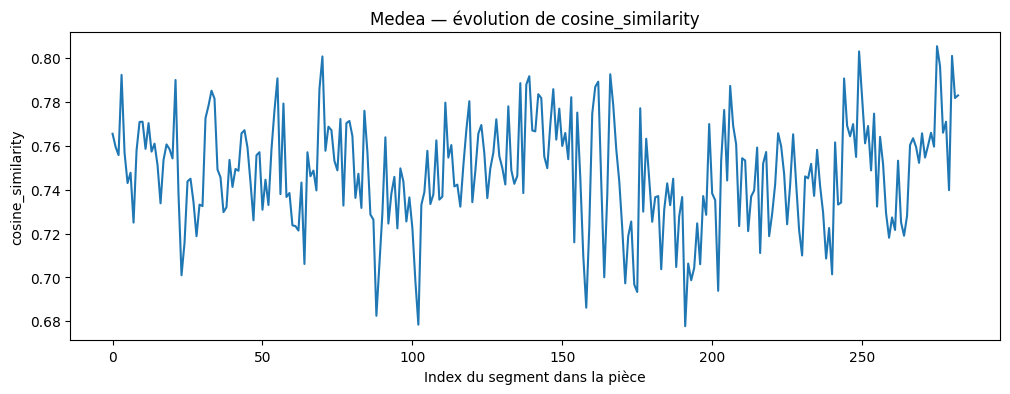

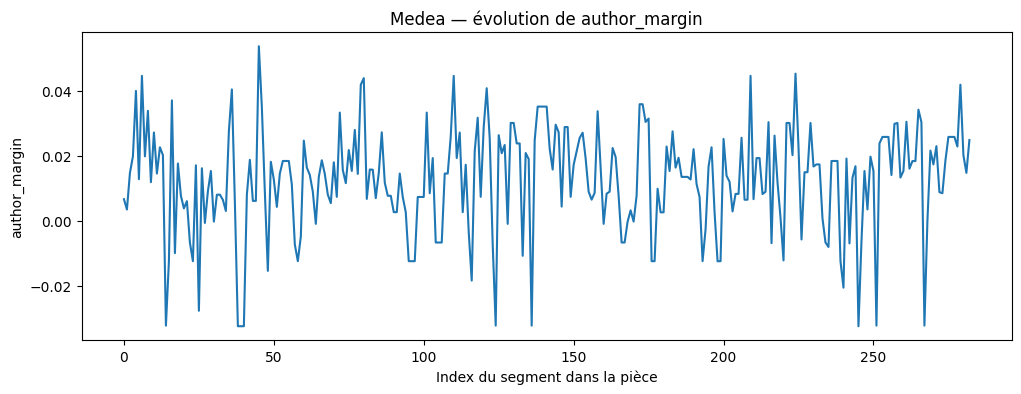

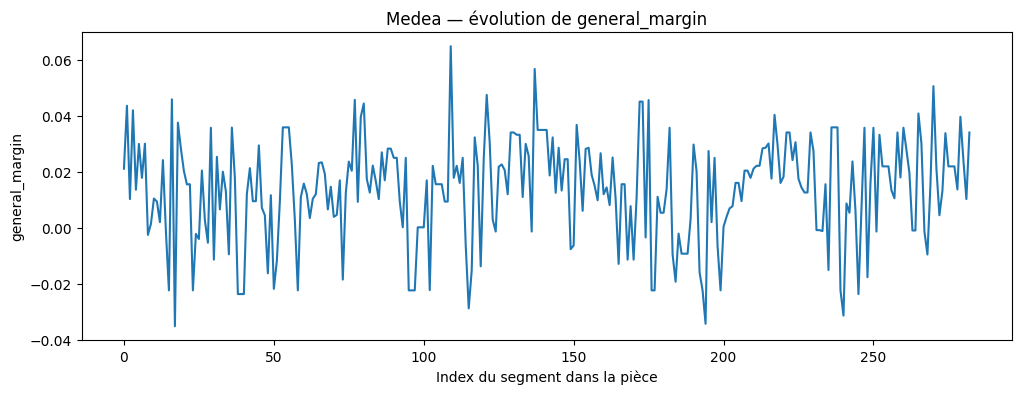

In [107]:
plot_proximity_timeline(matches_greek["thematic"], "Medea", score_col="cosine_similarity")
plot_proximity_timeline(matches_greek["thematic"], "Medea", score_col="author_margin")
plot_proximity_timeline(matches_greek["thematic"], "Medea", score_col="general_margin")

### timeline des auteurs dominants

In [108]:
def plot_author_timeline(matches_df, play_name):
    df = get_proximity_timeline(matches_df, play_name)

    author_to_num = {"aeschylus": 0, "sophocles": 1, "euripides": 2}
    num_to_author = {v: k for k, v in author_to_num.items()}

    y = df["target_author_group"].map(author_to_num)

    plt.figure(figsize=(12, 3))
    plt.scatter(df["source_segment_idx"], y)
    plt.yticks([0, 1, 2], ["aeschylus", "sophocles", "euripides"])
    plt.xlabel("Index du segment dans la pièce")
    plt.ylabel("Auteur grec apparié")
    plt.title(f"{play_name} — auteur grec dominant par segment")
    plt.show()

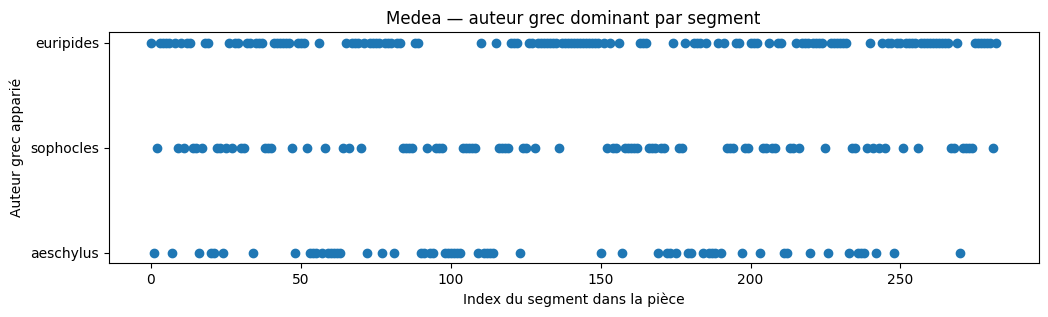

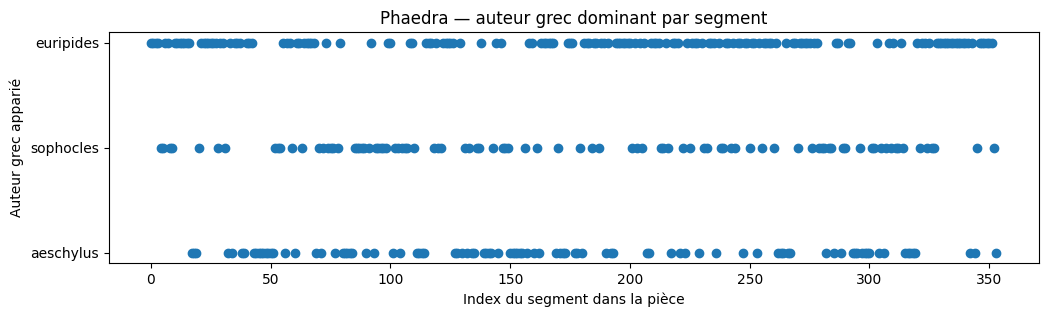

In [109]:
plot_author_timeline(matches_greek["thematic"], "Medea")
plot_author_timeline(matches_greek["structural"], "Phaedra")

In [110]:
def get_proximity_peaks(matches_df, play_name, score_col="cosine_similarity", top_n=15):
    df = get_proximity_timeline(matches_df, play_name)
    df = df.sort_values(score_col, ascending=False).head(top_n)

    return df.merge(
        matches_df[[
            "source_work_label",
            "source_segment_idx",
            "source_text",
            "target_author_group",
            "target_work_id",
            "target_work_label",
            "target_segment_idx",
            "target_text",
        ]],
        on=["source_segment_idx", "target_author_group", "target_work_id", "target_work_label", "target_segment_idx"],
        how="left"
    )

In [111]:
display(get_proximity_peaks(matches_greek["thematic"], "Medea", top_n=15))

,source_segment_idx,cosine_similarity,author_margin,general_margin,target_author_group,target_work_id,target_work_label,target_segment_idx,source_work_label,source_text,target_text
0,275,0.805519,0.025917,0.021949,euripides,tlg014,Ἑλένη,82,Medea,funus ac tumulum strue coniunx socerque iusta ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
1,249,0.803134,0.019855,0.015971,euripides,tlg005,Ἱππόλυτος,88,Medea,exitium senis armasse natas quaere materiam do...,θησεύς τιν ἡμάρτηκεν ἐς σ ἁμαρτίαν φαίδρα μὴ δ...
2,280,0.801100,0.020306,0.024191,euripides,tlg016,Ὀρέστης,488,Medea,ense viscera et ferro extraham ias iam perage ...,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...
3,70,0.800848,0.018110,0.003923,sophocles,tlg002,Ἀντιγόνη,11,Medea,ex omni tuli hoc est penes te si placet damna ...,οὐδέν ἀλλʼ ὃς ἂν τούτων τι δρᾷ φόνον προκεῖσθα...
4,276,0.796430,0.025917,0.021949,euripides,tlg014,Ἑλένη,82,Troades,latera cingebat mea lassabar in tot oscula et ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
5,276,0.796430,0.025917,0.021949,euripides,tlg014,Ἑλένη,82,Medea,dabitur exitio pari ias per numen omne perque ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
6,166,0.792724,-0.006567,0.015572,sophocles,tlg002,Ἀντιγόνη,177,Medea,artibus vocetur hecate sacra letifica appara s...,δόμος ἄτας οὐδὲν ἐλλείπει γενεᾶς ἐπὶ πλῆθος ἕρ...
7,3,0.792435,0.019976,0.041977,euripides,tlg006,Ἀνδρομάχη,359,Medea,raptam voce non fausta precor nunc nunc adeste...,οὐ σπαράξομαι κόμαν οὐκ ἐμῷ πιθήσομαι κάρᾳ κτύ...
8,139,0.791830,0.035244,0.034971,euripides,tlg005,Ἱππόλυτος,89,Medea,med hoc suades mihi praestas creusae paelicem ...,σ ἐξαίρει θανεῖν φαίδρα ἔα μ ἁμαρτεῖν οὐ γὰρ ἐ...
9,55,0.790850,0.018517,0.035890,aeschylus,tlg001,Ἱκέτιδες,99,Medea,iube cr aequum atque iniquum regis imperium fe...,κρατῶν μὴ καί ποτε εἴπῃ λεώς εἴ πού τι μὴ τοῖο...


In [112]:
import pandas as pd
from IPython.display import display, HTML

def display_full_peaks_table(matches_df, play_name, top_n=15, score_col="cosine_similarity"):
    df = get_proximity_peaks(matches_df, play_name, score_col=score_col, top_n=top_n).copy()

    cols = [
        "source_segment_idx",
        "target_author_group",
        "target_work_id",
        "target_segment_idx",
        "cosine_similarity",
        "author_margin",
        "general_margin",
        "source_text",
        "target_text",
    ]
    df = df[cols]

    # Arrondir les colonnes numériques pour la lisibilité
    for c in ["cosine_similarity", "author_margin", "general_margin"]:
        df[c] = df[c].round(4)

    # Affichage HTML avec retour à la ligne dans les cellules
    html = df.to_html(index=False, escape=False)
    html = html.replace('<table border="1" class="dataframe">',
                        '<table border="1" class="dataframe" style="table-layout:fixed; width:100%;">')
    html = html.replace('<td>', '<td style="white-space:pre-wrap; word-wrap:break-word; vertical-align:top; max-width:420px;">')
    html = html.replace('<th>', '<th style="white-space:pre-wrap; word-wrap:break-word; vertical-align:top;">')

    display(HTML(html))
    return df

In [113]:
display_full_peaks_table(matches_greek["thematic"], "Medea", top_n=15)

source_segment_idx,target_author_group,target_work_id,target_segment_idx,cosine_similarity,author_margin,general_margin,source_text,target_text
275,euripides,tlg014,82,0.8055,0.0259,0.0219,funus ac tumulum strue coniunx socerque iusta iam functis habent a me sepulti gnatus hic fatum tulit hic te vidente dabitur exitio pari ias per numen omne perque communes fugas torosque quos non nostra violavit fides iam parce nato si quod est crimen meum est me dedo morti noxium macta caput med hac qua recusas qua doles ferrum exigam i,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν καί μʼ ἀπαλλάξειν κακῶν οὗτος τέθνηκεν οὗτος οὐκέτʼ ἔστι δή μήτηρ δʼ ὄλωλε καὶ φονεὺς αὐτῆς ἐγώ ἀδίκως μέν ἀλλὰ τἄδικον τοῦτʼ ἔστʼ ἐμόν ὃ δʼ ἀγλάισμα δωμάτων ἐμοῦ τʼ ἔφυ θυγάτηρ ἄνανδρος πολιὰ παρθενεύεται τὼ τοῦ διὸς δὲ λεγομένω διοσκόρω οὐκ ἐστόν ἀλλὰ πάντʼ ἔχουσα δυστυχῆ τοῖς πράγμασιν τέθνηκα
249,euripides,tlg005,88,0.8031,0.0199,0.0160,exitium senis armasse natas quaere materiam dolor ad omne facinus non rudem dextram afferes quo te igitur ira mittis aut quae perfido intendis hosti tela nescio quid ferox decrevit animus intus et nondum sibi audet fateri stulta properavi nimis ex paelice utinam liberos hostis meus aliquos haberet quicquid ex illo tuum est creusa peperit placuit hoc poenae genus meritoque placuit,θησεύς τιν ἡμάρτηκεν ἐς σ ἁμαρτίαν φαίδρα μὴ δρῶσ ἔγωγ ἐκεῖνον ὀφθείην κακῶς τροφός τί γὰρ τὸ δεινὸν τοῦθ ὅ σ ἐξαίρει θανεῖν φαίδρα ἔα μ ἁμαρτεῖν οὐ γὰρ ἐς σὲ ἁμαρτάνω τροφός οὐ δῆθ ἑκοῦσά γ ἐν δὲ σοὶ λελείψομαι φαίδρα τί δρᾷς βιάζῃ χειρὸς ἐξαρτωμένη τροφός καὶ σῶν γε γονάτων κοὐ μεθήσομαί ποτε φαίδρα κάκ ὦ τάλαινα σοὶ
280,euripides,tlg016,488,0.8011,0.0203,0.0242,ense viscera et ferro extraham ias iam perage coeptum facinus haut ultra precor moramque saltem supplicis dona meis med perfruere lento scelere ne propera dolor meus dies est tempore accepto utimur ias infesta memet perime med misereri iubes bene est peractum est plura non habui dolor quae tibi litarem lumina huc tumida alleva ingrate iason coniugem agnoscis tuam sic fugere,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξας παλαιὰ γεῖσα τεκτόνων πόνον μοχλοῖς δʼ ἄραρε κλῇθρα σῆς βοηδρόμου σπουδῆς ἅ σʼ εἴρξει μὴ δόμων ἔσω περᾶν μενέλαος ἔα τί χρῆμα λαμπάδων ὁρῶ σέλας δόμων δʼ ἐπʼ ἄκρων τούσδε πυργηρουμένους ξίφος δʼ ἐμῆς θυγατρὸς ἐπίφρουρον δέρῃ ὀρέστης πότερον ἐρωτᾶν ἢ κλύειν ἐμοῦ θέλεις μενέλαος οὐδέτερʼ ἀνάγκη δʼ ὡς ἔοικε σου κλύειν
70,sophocles,tlg002,11,0.8008,0.0181,0.0039,ex omni tuli hoc est penes te si placet damna ream sed redde crimen sum nocens fateor creo talem sciebas esse cum genua attigi fidemque supplex praesidis dextrae peti terra hac miseriis angulum ac sedem rogo latebrasque viles urbe si pelli placet detur remotus aliquis in regnis locus cr non esse me qui sceptra violentus geram nec qui superbo miserias,οὐδέν ἀλλʼ ὃς ἂν τούτων τι δρᾷ φόνον προκεῖσθαι δημόλευστον ἐν πόλει οὕτως ἔχει σοι ταῦτα καὶ δείξεις τάχα εἴτʼ εὐγενὴς πέφυκας εἴτʼ ἐσθλῶν κακή ἰσμήνη τί δʼ ὦ ταλαῖφρον εἰ τάδʼ ἐν τούτοις ἐγὼ λύουσʼ ἂν ἢ ʼφάπτουσα προσθείμην πλέον ἀντιγόνη εἰ ξυμπονήσεις καὶ ξυνεργάσει σκόπει ἰσμήνη ποῖόν τι κινδύνευμα ποῦ γνώμης ποτʼ εἶ ἀντιγόνη εἰ τὸν νεκρὸν ξὺν
276,euripides,tlg014,82,0.7964,0.0259,0.0219,latera cingebat mea lassabar in tot oscula et tantum gregem dividere matrem sola nunc haec est super votum comes levamen afflictae quies haec totus hecubae fetus hac sola vocor iam voce mater dura et infelix age elabere anima denique hoc unum mihi remitte funus inrigat fletus genas imberque victo subitus e vultu cadit andr nos hecuba nos nos hecuba lugendae,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν καί μʼ ἀπαλλάξειν κακῶν οὗτος τέθνηκεν οὗτος οὐκέτʼ ἔστι δή μήτηρ δʼ ὄλωλε καὶ φονεὺς αὐτῆς ἐγώ ἀδίκως μέν ἀλλὰ τἄδικον τοῦτʼ ἔστʼ ἐμόν ὃ δʼ ἀγλάισμα δωμάτων ἐμοῦ τʼ ἔφυ θυγάτηρ ἄνανδρος πολιὰ παρθενεύεται τὼ τοῦ διὸς δὲ λεγομένω διοσκόρω οὐκ ἐστόν ἀλλὰ πάντʼ ἔχουσα δυστυχῆ τοῖς πράγμασιν τέθνηκα
276,euripides,tlg014,82,0.7964,0.0259,0.0219,dabitur exitio pari ias per numen omne perque co

,source_segment_idx,target_author_group,target_work_id,target_segment_idx,cosine_similarity,author_margin,general_margin,source_text,target_text
0,275,euripides,tlg014,82,0.8055,0.0259,0.0219,funus ac tumulum strue coniunx socerque iusta ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
1,249,euripides,tlg005,88,0.8031,0.0199,0.0160,exitium senis armasse natas quaere materiam do...,θησεύς τιν ἡμάρτηκεν ἐς σ ἁμαρτίαν φαίδρα μὴ δ...
2,280,euripides,tlg016,488,0.8011,0.0203,0.0242,ense viscera et ferro extraham ias iam perage ...,θράσει ἢ τῷδε θριγκῷ κρᾶτα συνθραύσω σέθεν ῥήξ...
3,70,sophocles,tlg002,11,0.8008,0.0181,0.0039,ex omni tuli hoc est penes te si placet damna ...,οὐδέν ἀλλʼ ὃς ἂν τούτων τι δρᾷ φόνον προκεῖσθα...
4,276,euripides,tlg014,82,0.7964,0.0259,0.0219,latera cingebat mea lassabar in tot oscula et ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
5,276,euripides,tlg014,82,0.7964,0.0259,0.0219,dabitur exitio pari ias per numen omne perque ...,δʼ ἥ μου τὰς τύχας ὤχει μόνη πόσιν ποθʼ ἥξειν ...
6,166,sophocles,tlg002,177,0.7927,-0.0066,0.0156,artibus vocetur hecate sacra letifica appara s...,δόμος ἄτας οὐδὲν ἐλλείπει γενεᾶς ἐπὶ πλῆθος ἕρ...
7,3,euripides,tlg006,359,0.7924,0.0200,0.0420,raptam voce non fausta precor nunc nunc adeste...,οὐ σπαράξομαι κόμαν οὐκ ἐμῷ πιθήσομαι κάρᾳ κτύ...
8,139,euripides,tlg005,89,0.7918,0.0352,0.0350,med hoc suades mihi praestas creusae paelicem ...,σ ἐξαίρει θανεῖν φαίδρα ἔα μ ἁμαρτεῖν οὐ γὰρ ἐ...
9,55,aeschylus,tlg001,99,0.7909,0.0185,0.0359,iube cr aequum atque iniquum regis imperium fe...,κρατῶν μὴ καί ποτε εἴπῃ λεώς εἴ πού τι μὴ τοῖο...
